<a href="https://colab.research.google.com/github/acshon99/consumer-behavior/blob/main/Additional_Analyses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sohaibdevv/consumer-shopping-behavior-and-preference-study-2026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'consumer-shopping-behavior-and-preference-study-2026' dataset.
Path to dataset files: /kaggle/input/consumer-shopping-behavior-and-preference-study-2026


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numerical features for clustering. We'll exclude the one-hot encoded original columns and reconstructed categories.
# We will use the 'behavioral_scores' defined earlier, and add other relevant numerical features.
features_for_clustering = ['age', 'monthly_income', 'daily_internet_hours', 'smartphone_usage_years',
                           'social_media_hours', 'online_payment_trust_score', 'tech_savvy_score',
                           'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
                           'avg_store_spend', 'discount_sensitivity', 'return_frequency',
                           'avg_delivery_days', 'delivery_fee_sensitivity', 'free_return_importance',
                           'product_availability_online', 'impulse_buying_score',
                           'need_touch_feel_score', 'brand_loyalty_score', 'environmental_awareness',
                           'time_pressure_level']

# Create a copy of the DataFrame with selected features
X = df[features_for_clustering].copy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

print("Scaled data head:")
display(X_scaled_df.head())


Scaled data head:


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
0,0.406208,1.312530,0.247193,1.097374,-1.436643,-1.561941,0.161298,-0.601329,1.137778,-1.065762,...,-0.508597,-1.001936,0.185073,0.533633,0.516583,-1.558966,-0.863832,0.164279,-0.156148,-1.218212
1,1.132518,-0.523729,1.107201,1.346660,0.146896,0.174023,1.200393,-0.739923,-1.480671,1.146779,...,0.877727,0.000170,-1.557043,-0.854266,-0.529628,1.220939,0.178869,0.866360,-1.548606,0.520048
2,-0.152492,-1.653741,0.196604,-0.896913,-0.328166,1.562795,0.854028,-1.571486,-1.655234,0.171065,...,-0.162016,0.501223,-0.860196,-0.507291,1.562793,-1.558966,-1.558966,-0.888842,-0.852377,-0.870560
3,-0.934672,-1.152918,0.196604,0.848088,-1.436643,-1.214748,1.546757,-0.324142,-1.131544,-0.895486,...,-1.548341,-0.500883,-0.860196,1.574557,-1.227102,-0.516501,0.874003,-1.239882,0.191966,0.172396
4,0.629688,1.648786,-0.005750,-0.647627,-1.436643,-1.214748,-0.185067,-0.462735,1.137778,1.330144,...,1.570889,-1.001936,-0.511773,-1.201240,-0.180891,0.873451,1.221571,0.515320,-1.548606,0.172396


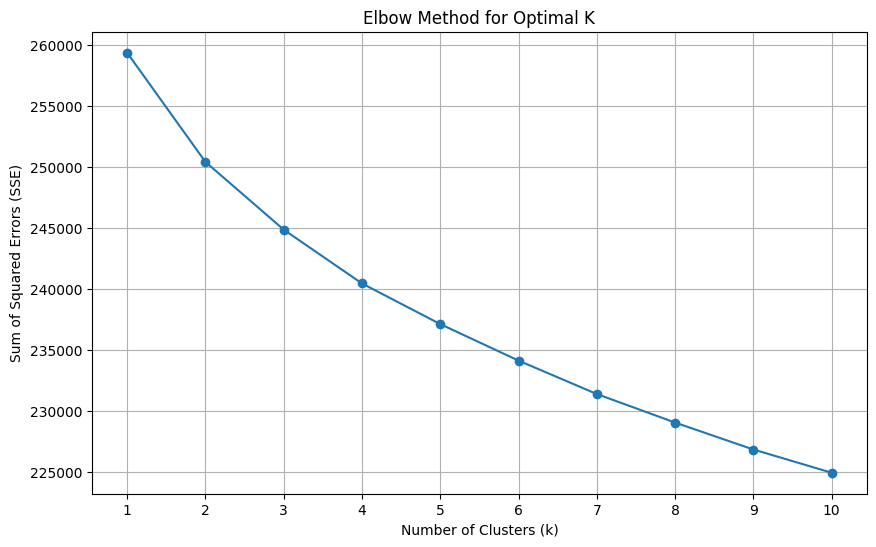

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize a list to store the Sum of Squared Errors (SSE)
sse = []

# Define a range of k values to test
k_range = range(1, 11) # Testing from 1 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_scaled_df)
    sse.append(kmeans.inertia_) # inertia is the SSE

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# --- K-Means with k=3 ---
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_3 = kmeans_3.fit_predict(X_scaled_df)

silhouette_3 = silhouette_score(X_scaled_df, clusters_3)
davies_bouldin_3 = davies_bouldin_score(X_scaled_df, clusters_3)

print(f"\nEvaluation for K=3 Clusters:")
print(f"Silhouette Score: {silhouette_3:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_3:.4f}")

# --- K-Means with k=4 ---
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_4 = kmeans_4.fit_predict(X_scaled_df)

silhouette_4 = silhouette_score(X_scaled_df, clusters_4)
davies_bouldin_4 = davies_bouldin_score(X_scaled_df, clusters_4)

print(f"\nEvaluation for K=4 Clusters:")
print(f"Silhouette Score: {silhouette_4:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_4:.4f}")

# Add cluster labels to the original DataFrame for further analysis
df['cluster_3'] = clusters_3
df['cluster_4'] = clusters_4



Evaluation for K=3 Clusters:
Silhouette Score: 0.0287
Davies-Bouldin Index: 4.7743

Evaluation for K=4 Clusters:
Silhouette Score: 0.0286
Davies-Bouldin Index: 4.6394


# Explanation:

By appying K-Mean clustering with k=3 and k=4, the evaluation metrics and visualizations provide insights into the quality of the clusters.
- **Low silhouette scores**: Both k=3 and k=4 yielded very low silhouette scores. A silhouette score close to 0 indicaes that the clusters are either overlapping or that the data points are very close to the decision boundary of neighboring clusters. It suggests that there is poor seperation between the clusters.
- **Average Characteristics**: While profiling the average characteristics for each cluster reveals some differences, the low evaluation scores imply that these differences are not strong enough to create truly distinct and reliable segments.,

The K-means clustering analysis indicates that the current feature set is not sufficient to achieve robust and well-seperated customer segments. The clusters are highly overlapping, suggesting that the underlying structure for clear segmentation may be missing or require different features.

In [ ]:
# Define features (X) and target (y)
# Exclude the target itself, and reconstructed categorical columns from features
features_for_regression = [col for col in df.columns if col not in ['avg_online_spend', 'shopping_preference_category', 'city_tier_category', 'age_group', 'income_group', 'gender_category', 'cluster_3', 'cluster_4']]

X = df[features_for_regression]
y = df['avg_online_spend']

print(f"Features for regression: {X.shape[1]} columns")
print(f"Target variable: {y.name}")
display(X.head())

Features for regression: 27 columns
Target variable: avg_online_spend


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_store_spend,...,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender_Male,gender_Other,city_tier_Tier 2,city_tier_Tier 3,shopping_preference_Online,shopping_preference_Store
0,56,221111,6.5,12,0.7,1,6,16,16,144092,...,3,6,5,2,False,True,False,True,False,True
1,69,96029,8.2,13,2.7,6,9,14,1,28421,...,6,8,1,7,True,False,False,True,False,False
2,46,19055,6.4,4,2.1,10,8,2,0,128229,...,1,3,3,3,False,False,False,True,False,True
3,32,53170,6.4,11,0.7,2,10,20,3,134650,...,8,2,6,6,False,False,False,False,False,True
4,60,244016,6.0,5,0.7,2,5,18,16,34122,...,9,7,1,6,True,False,False,True,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 9431 samples
Testing set size: 2358 samples


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae:.2f}")
print(f"  Mean Squared Error (MSE): {mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"  R-squared (R2): {r2:.4f}")

Linear Regression Model Performance:
  Mean Absolute Error (MAE): 37612.87
  Mean Squared Error (MSE): 1891132056.35
  Root Mean Squared Error (RMSE): 43487.15
  R-squared (R2): -0.0022


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf**0.5
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Model Performance:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.4f}")

Random Forest Regressor Model Performance:
  Mean Absolute Error (MAE): 37797.85
  Mean Squared Error (MSE): 1923839249.12
  Root Mean Squared Error (RMSE): 43861.59
  R-squared (R2): -0.0195


Top 10 Feature Importances:


,Feature,Importance
1,monthly_income,0.081308
9,avg_store_spend,0.077731
2,daily_internet_hours,0.066033
0,age,0.062680
7,monthly_online_orders,0.060925
4,social_media_hours,0.060923
8,monthly_store_visits,0.046980
3,smartphone_usage_years,0.043251
13,delivery_fee_sensitivity,0.038129
11,return_frequency,0.036914


/tmp/ipykernel_11234/3813469289.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')


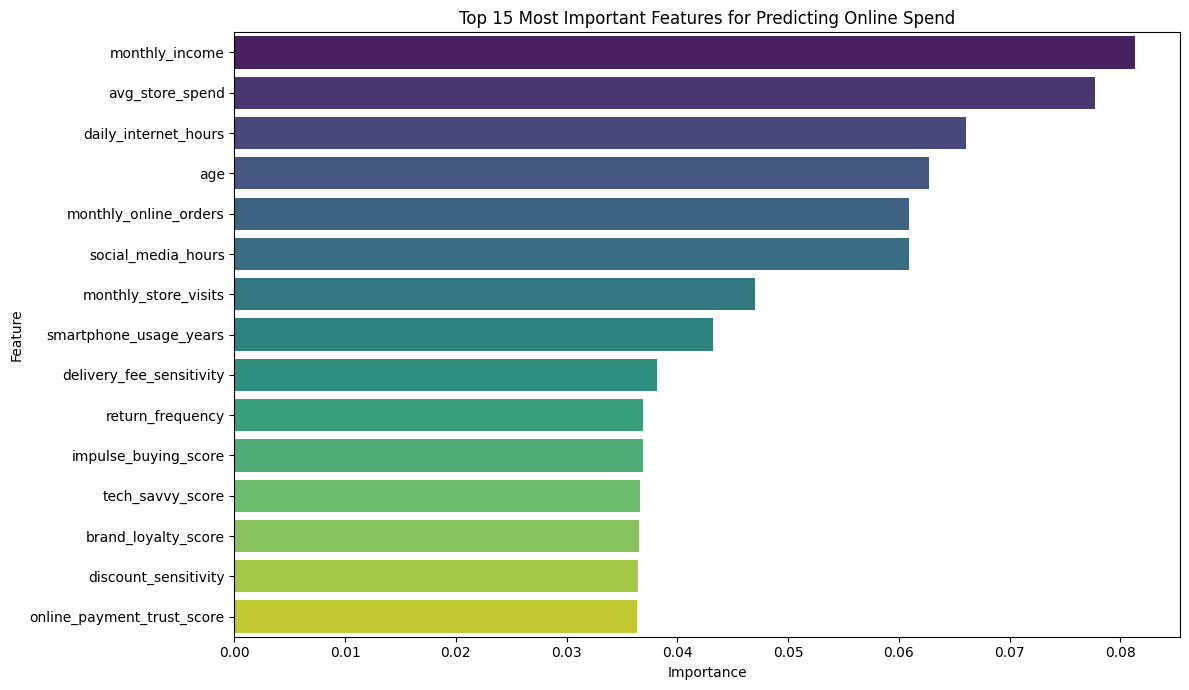

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances:")
display(features_df.head(10))

# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')
plt.title('Top 15 Most Important Features for Predicting Online Spend')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()